In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Import the data from medical_examination.csv and assign it to the df variable
df = pd.read_csv('medical_examination.csv')

# 2. Add 'overweight' column based on BMI > 25
df['overweight'] = (df['weight'] / ((df['height'] / 100) ** 2) > 25).astype(int)

# 3. Normalize cholesterol and gluc: 1 stays 0 (good), >1 becomes 1 (bad)
df['cholesterol'] = df['cholesterol'].apply(lambda x: 0 if x == 1 else 1)
df['gluc'] = df['gluc'].apply(lambda x: 0 if x == 1 else 1)

# 4. Draw the Categorical Plot in the draw_cat_plot function
def draw_cat_plot():
    # 5. Create DataFrame for cat plot using pd.melt
    df_cat = pd.melt(df, id_vars=['cardio'], 
                     value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'],
                     var_name='variable', value_name='value')

    # 6. Group and reformat the data to split by cardio and show counts
    df_cat = df_cat.groupby(['cardio', 'variable', 'value'], as_index=False).size()
    df_cat = df_cat.rename(columns={'size': 'total'})

    # 7. Create the catplot using seaborn
    fig = sns.catplot(x='variable', y='total', hue='value', col='cardio',
                      data=df_cat, kind='bar', height=5, aspect=1).fig

    # 8. Get the figure for output
    fig = fig

    # 9. Do not modify
    fig.savefig('catplot.png')
    return fig


# 10. Draw the Heat Map in the draw_heat_map function
def draw_heat_map():
    # 11. Clean the data
    df_heat = df[
        (df['ap_lo'] <= df['ap_hi']) &
        (df['height'] >= df['height'].quantile(0.025)) &
        (df['height'] <= df['height'].quantile(0.975)) &
        (df['weight'] >= df['weight'].quantile(0.025)) &
        (df['weight'] <= df['weight'].quantile(0.975))
    ]

    # 12. Calculate the correlation matrix
    corr = df_heat.corr()

    # 13. Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # 14. Set up the matplotlib figure
    fig, ax = plt.subplots(figsize=(12, 10))

    # 15. Plot the correlation matrix using seaborn heatmap
    sns.heatmap(corr, mask=mask, annot=True, fmt='.1f', center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax)

    # 16. Do not modify
    fig.savefig('heatmap.png')
    return fig

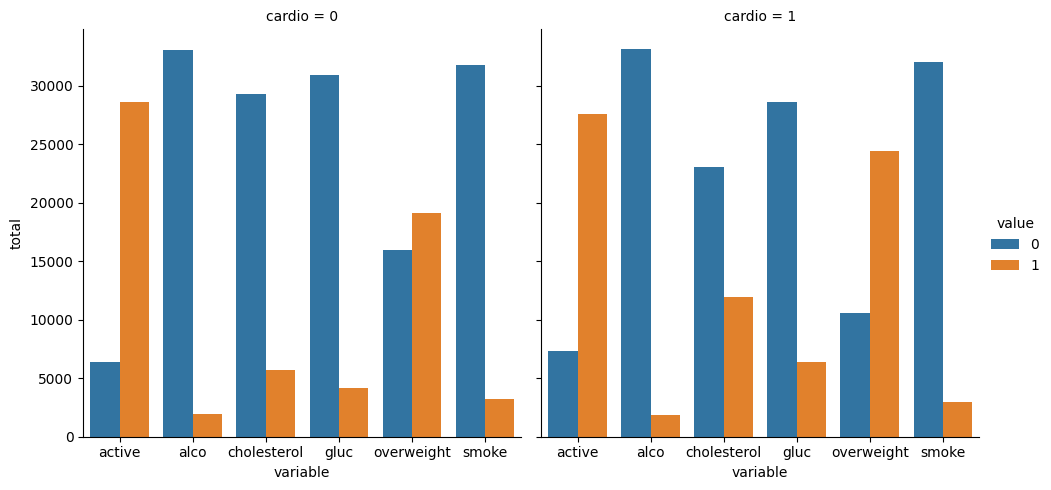

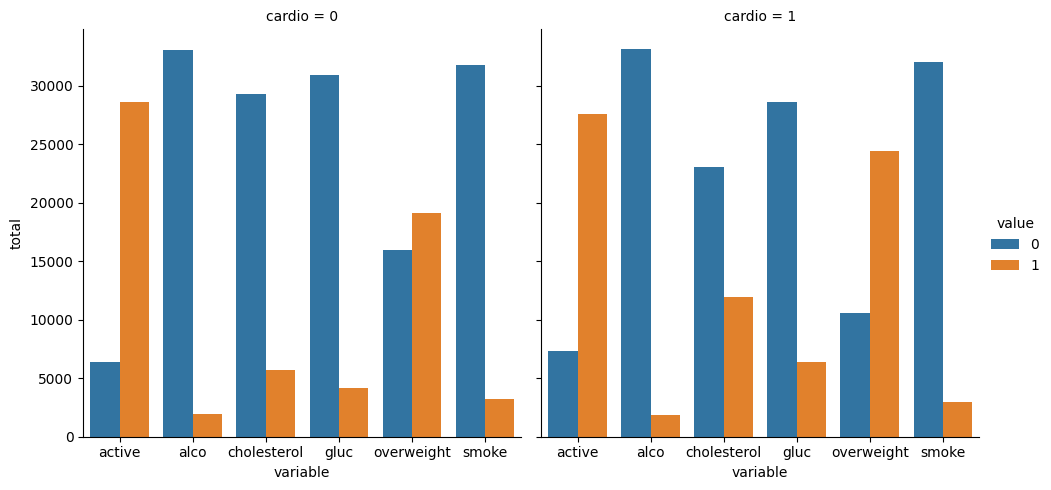

In [2]:
draw_cat_plot()